# Task 4 - Final hold-out evaluation

## Evaluation objective and scope

The development sequence now has a clear empirical direction. The development results show a clear sequence. CAE learns useful visual signal but weak semantic separation. Triplet makes the first large improvement, SupCon further improves the inner-validation result, Multi-Similarity does not improve the ranking, and ArcFace produces the strongest inner-validation result. The remaining question is no longer which mechanism to try next, but whether that ordering holds when every frozen model sees the same unseen queries and the same gallery.

This notebook therefore performs the only cross-model hold-out decision. Relevance is still defined by the train-fitted `articleType__gender` proxy, and no model, preprocessing statistic or hyperparameter is fitted here. Raw cosine ranking is reported separately from optional reranking so that representation quality is not confused with post-processing. The judgement combines ranking metrics, query coverage, embedding geometry, artifact footprint and qualitative errors rather than reducing the system to one score.


### Hold-out evaluation pipeline

![Final benchmark flow](figures/06_benchmark_flow.svg)

*Figure 1. Frozen models are compared through one controlled retrieval pipeline. Raw and reranked evidence remain separate so post-processing cannot be mistaken for representation quality [1], [2].*


## 1. Environment and reproducibility

All metric-learning models receive the deterministic letterbox, tensor conversion, and training-set RGB normalisation saved by notebook 00. The CAE receives unnormalised `[0, 1]` pixels to match its reconstruction training. The random seed fixes qualitative example selection and loader order; CUDA kernels may still not be bitwise deterministic.

All candidates use a 512-D L2-normalised embedding, so inner-product FAISS search is cosine ranking [1]. ArcFace's training-only class head is excluded at inference; Triplet, SupCon, MS, and ArcFace therefore deploy the same ResNet-18 encoder capacity.


In [13]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while (
    PROJECT_ROOT != PROJECT_ROOT.parent
    and not (PROJECT_ROOT / "pyproject.toml").exists()
):
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [14]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image

from src.task4.config import (
    ARTIFACT_DIR,
    CONFIG_DIR,
    IMAGE_DIR,
    MODEL_DIR,
    SEED,
    SPLIT_DIR,
)
from src.task4.data import make_evaluation_loader
from src.task4.models import ConvolutionalAutoencoder, ResNet18Encoder
from src.task4.preprocessing import cae_transform, metric_eval_transform
from src.task4.retrieval import (
    extract_color_descriptors,
    extract_embeddings,
    k_reciprocal_rerank,
    retrieval_metrics,
    search_cosine,
)
from src.task4.training import DEVICE, set_seed

set_seed(SEED)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

MODEL_NAMES = ("cae", "triplet", "supcon", "multi_similarity", "arcface")
EVALUATION_TRANSFORMS = {
    "cae": cae_transform,
    "triplet": metric_eval_transform,
    "supcon": metric_eval_transform,
    "multi_similarity": metric_eval_transform,
    "arcface": metric_eval_transform,
}
PRIMARY_METRIC = "mAP@10"
RERANK_CONFIG = {
    "k1": 20,
    "k2": 6,
    "blend": 0.3,
    "candidate_depth": 100,
    "color_weight": 0.15,
}
BENCHMARK_DIR = ARTIFACT_DIR / "benchmark"
EMBEDDING_DIR = ARTIFACT_DIR / "embeddings"
print(f"Device: {DEVICE}")

Device: cpu


## 2. Artifact validation and hold-out test set

The preflight requires `best.pt` for every trained candidate. Section 4 extracts fresh embeddings for the common gallery and queries and saves the resulting bundles under `artifacts/task4/embeddings/`. Missing checkpoints therefore fail early instead of silently changing the five-model comparison; large model and dataset artifacts are distributed separately from Git.

Test labels are recreated with the train-fitted encoder. Three query rows with encoder-unseen joint labels are excluded, leaving **3,774 of 3,777 hold-out queries (99.92% coverage)**. The current **33,968-image outer-training gallery** contains relevant items for every retained query class, so no further query filtering is performed. This is closed-set evaluation of the `articleType__gender` proxy, and the three exclusions remain part of the reported coverage.


In [ ]:
artifact_rows = []
for model_name in MODEL_NAMES:
    model_dir = MODEL_DIR / model_name
    checkpoint_exists = (model_dir / "best.pt").exists()
    artifact_rows.append(
        {
            "Model": model_name,
            "Checkpoint ready": checkpoint_exists,
        }
    )

artifact_status = pd.DataFrame(artifact_rows)
display(artifact_status)

missing_models = artifact_status.loc[
    ~artifact_status["Checkpoint ready"], "Model"
].tolist()
if missing_models:
    raise FileNotFoundError(
        "Final benchmark requires all five best.pt checkpoints. Missing: "
        + ", ".join(missing_models)
    )

if not IMAGE_DIR.exists():
    raise FileNotFoundError(f"Hold-out images are not available at {IMAGE_DIR}")

,Model,Checkpoint ready
0,cae,True
1,triplet,True
2,supcon,True
3,multi_similarity,True
4,arcface,True


### Artifact provenance

The galleries stored alongside training checkpoints describe earlier development experiments and can contain fewer images than the final outer-training split. They are not the gallery used by this notebook. Section 4 independently embeds the common **33,968 gallery images and 3,774 queries** for each frozen checkpoint, saving ordered IDs and embeddings under `artifacts/task4/embeddings/<model>/`.

The rendered tables and numerical interpretation retained in Sections 5–6 document a **previous saved execution**. Existing benchmark CSVs contain different scores, so they must not be mixed with that historical narrative. Section 7 explicitly validates the full ArcFace embedding IDs and recomputes its metrics with the same protocol as FashionCLIP; it does not copy scores from an older table or the smaller development galleries.


In [16]:
with (CONFIG_DIR / "articleType_gender_label_encoder.json").open(
    encoding="utf-8"
) as file:
    label_encoder = json.load(file)
label_to_index = label_encoder["label_to_index"]
classes = np.asarray(label_encoder["classes"], dtype=object)
LABEL_COLUMN = label_encoder["label_column"]
LABEL_ID_COLUMN = label_encoder["label_id_column"]
separator = label_encoder["separator"]

outer_train_df = pd.read_csv(SPLIT_DIR / "train.csv")
outer_train_df[LABEL_COLUMN] = (
    outer_train_df["articleType"].str.strip()
    + separator
    + outer_train_df["gender"].str.strip()
)
outer_train_df[LABEL_ID_COLUMN] = outer_train_df[LABEL_COLUMN].map(label_to_index)

test_df = pd.read_csv(SPLIT_DIR / "test.csv")
test_df[LABEL_COLUMN] = (
    test_df["articleType"].str.strip() + separator + test_df["gender"].str.strip()
)
test_df[LABEL_ID_COLUMN] = test_df[LABEL_COLUMN].map(label_to_index)


In [17]:
test_rows_before_filtering = len(test_df)
unseen_class_mask = test_df[LABEL_ID_COLUMN].isna()
removed_unseen_rows = int(unseen_class_mask.sum())
test_df = test_df.loc[~unseen_class_mask].copy()
test_df[LABEL_ID_COLUMN] = test_df[LABEL_ID_COLUMN].astype("int64")

print(f"Hold-out test rows before filtering: {test_rows_before_filtering:,}")
print(f"Rows removed for encoder-unseen classes: {removed_unseen_rows:,}")
print(f"Seen-class test rows retained: {len(test_df):,}")


Hold-out test rows before filtering: 3,777
Rows removed for encoder-unseen classes: 3
Seen-class test rows retained: 3,774


## 3. Model loading

Each checkpoint is restored in evaluation mode. ArcFace's class-centre head is training-only and removed before loading the common encoder. The CAE currently loads its decoder as well because its forward method returns both reconstruction and embedding; an encoder-only deployment would reduce CAE latency and memory without changing its retrieval vector.


In [6]:
def build_model(model_name: str):
    return (
        ConvolutionalAutoencoder(ResNet18Encoder())
        if model_name == "cae"
        else ResNet18Encoder()
    )


def load_model(model_name: str):
    checkpoint = torch.load(
        MODEL_DIR / model_name / "best.pt", map_location=DEVICE, weights_only=False
    )
    state_dict = checkpoint["model_state_dict"]
    if model_name == "arcface":
        state_dict = {
            key: value
            for key, value in state_dict.items()
            if not key.startswith("arcface_loss.")
        }

    model = build_model(model_name)
    model.load_state_dict(state_dict)
    return model.to(DEVICE).eval()

## 4. Hold-out retrieval benchmark

This section compares the five frozen models under one controlled retrieval protocol. Every model receives the same outer-training gallery and filtered outer-test queries, then produces both a conventional cosine ranking and an enhanced ranking using k-reciprocal context with HSV colour information. Reporting both versions separates the quality learned by the encoder from the effect of retrieval-time post-processing.

The data preparation, embedding extraction, colour branch, and two ranking paths are explained immediately before their corresponding cells below.


### Common gallery and query rows

The benchmark fixes the evaluation data before any model is compared:

- **Gallery:** all **33,968 outer-training images**.
- **Queries:** **3,774 outer-test images** after removing three rows whose labels were unseen by the train-fitted encoder.
- **Alignment:** IDs are sorted once so embeddings, HSV descriptors, and metric labels refer to the same items in the same order.

Labels are reconstructed from the CSV files by ID and are used only after retrieval to score the rankings; they are not inputs to the models or reranker.


In [7]:
gallery_df = outer_train_df.sort_values("id").reset_index(drop=True)
evaluation_df = test_df.sort_values("id").reset_index(drop=True)
gallery_df[LABEL_ID_COLUMN] = gallery_df[LABEL_ID_COLUMN].astype("int64")

gallery_classes = set(gallery_df[LABEL_ID_COLUMN])
missing_query_classes = set(evaluation_df[LABEL_ID_COLUMN]) - gallery_classes
if missing_query_classes:
    raise ValueError(
        f"{len(missing_query_classes)} query classes have no relevant gallery item"
    )

expected_gallery_ids = gallery_df["id"].to_numpy(dtype="int64")
expected_query_ids = evaluation_df["id"].to_numpy(dtype="int64")
gallery_label_by_id = gallery_df.set_index("id")[LABEL_ID_COLUMN]
query_label_by_id = evaluation_df.set_index("id")[LABEL_ID_COLUMN]

print(f"Common outer-training gallery: {len(gallery_df):,} images")
print(f"Scored hold-out queries: {len(evaluation_df):,} images")
print(f"Excluded encoder-unseen queries: {removed_unseen_rows:,} images")

Common outer-training gallery: 33,968 images
Scored hold-out queries: 3,774 images
Excluded encoder-unseen queries: 3 images


### Per-model embedding extraction

Each frozen checkpoint independently embeds the common gallery and query rows. The model-specific differences are limited to the learned weights and the preprocessing required by training:

- **CAE** uses its reconstruction-compatible transform.
- **Triplet, SupCon, Multi-Similarity, and ArcFace** use the metric-learning evaluation transform.
- **Each model bundle** stores its 512-D gallery/query embeddings and ordered IDs.

This keeps the comparison reproducible and prevents vectors from different checkpoints from being mixed. It also avoids relying on the smaller inner-validation galleries created during model development.


In [20]:
for model_name in MODEL_NAMES:
    model = load_model(model_name)
    transform = EVALUATION_TRANSFORMS[model_name]

    gallery_loader = make_evaluation_loader(gallery_df, transform, IMAGE_DIR)
    query_loader = make_evaluation_loader(evaluation_df, transform, IMAGE_DIR)

    gallery_embeddings, gallery_ids, extracted_gallery_labels = extract_embeddings(
        model, gallery_loader
    )
    query_embeddings, query_ids, extracted_query_labels = extract_embeddings(
        model, query_loader
    )

    bundle_dir = EMBEDDING_DIR / model_name
    bundle_dir.mkdir(parents=True, exist_ok=True)
    np.save(bundle_dir / "gallery_embeddings.npy", gallery_embeddings)
    np.save(bundle_dir / "gallery_ids.npy", gallery_ids)
    np.save(bundle_dir / "query_embeddings.npy", query_embeddings)
    np.save(bundle_dir / "query_ids.npy", query_ids)

    print(f"{model_name}: saved benchmark embeddings successfully")

cae: saved benchmark embeddings successfully
triplet: saved benchmark embeddings successfully
supcon: saved benchmark embeddings successfully
multi_similarity: saved benchmark embeddings successfully
arcface: saved benchmark embeddings successfully


### HSV colour descriptors

The models were trained with `articleType__gender` supervision, so they are encouraged to represent product type and intended gender but are not explicitly required to preserve colour. HSV histograms add that visual cue at retrieval time:

- **Hue** represents dominant colour.
- **Saturation and value** help distinguish muted, vivid, light, and dark items.
- **Image-only extraction** introduces no label or metadata information into ranking.

The descriptors are computed once because all five models use the same ordered gallery and query IDs.


In [9]:
gallery_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_gallery_ids
)

query_color_descriptors = extract_color_descriptors(
    IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_query_ids
)

# Preserve the exact row order for safe reuse in the external comparison.
gallery_color_ids = expected_gallery_ids.copy()
query_color_ids = expected_query_ids.copy()


### Raw ranking versus k-reciprocal and colour reranking

The two ranking paths answer different evaluation questions:

- **Raw cosine ranking — representation quality.** Exact cosine similarity ranks every gallery embedding for each query. No colour feature or neighbourhood heuristic changes the order, so this is the clearest view of what the encoder learned.
- **K-reciprocal reranking — neighbourhood consistency.** Reranking starts from the top 100 cosine candidates and favours candidates supported by mutually consistent neighbourhoods. An isolated high cosine match can move down when its surrounding neighbours do not agree. K-reciprocal reasoning does **not** inspect colour.
- **HSV blending — colour consistency.** HSV similarity is blended into the reranking distance with weight `0.15`, allowing similarly coloured products to move upward within the candidate pool while the learned embedding remains the dominant signal. The remaining settings are fixed for every model: `k1=20`, `k2=6`, and original/Jaccard blend `0.3`. The method is inspired by Zhong *et al.* [2], rather than being an exact reproduction.

A colour-aware ranking may look more convincing to a customer, but the benchmark relevance label is only `articleType__gender` and does not directly reward colour. Reranking may therefore increase metrics when colour supports the semantic neighbourhood, leave them almost unchanged when it only reorders relevant items, or reduce them when colour promotes an item from the wrong proxy class. Reporting both paths for all five models exposes this trade-off instead of assuming that additional post-processing must improve retrieval.


In [ ]:
model_outputs = {}
raw_summary_rows = []
reranked_summary_rows = []

for model_name in MODEL_NAMES:
    bundle_dir = EMBEDDING_DIR / model_name

    saved_gallery_embeddings = np.load(bundle_dir / "gallery_embeddings.npy").astype(
        "float32", copy=False
    )
    saved_query_embeddings = np.load(bundle_dir / "query_embeddings.npy").astype(
        "float32", copy=False
    )

    saved_gallery_ids = np.load(bundle_dir / "gallery_ids.npy").astype(
        "int64", copy=False
    )
    saved_query_ids = np.load(bundle_dir / "query_ids.npy").astype("int64", copy=False)

    gallery_labels = gallery_label_by_id.reindex(saved_gallery_ids)
    query_labels = query_label_by_id.reindex(saved_query_ids)

    saved_gallery_labels = gallery_labels.to_numpy(dtype="int64")
    saved_query_labels = query_labels.to_numpy(dtype="int64")

    _, raw_ranked_indices, index = search_cosine(
        saved_query_embeddings, saved_gallery_embeddings, maximum_k=10
    )
    reranked_indices = k_reciprocal_rerank(
        saved_query_embeddings,
        saved_gallery_embeddings,
        index,
        query_color_descriptors=query_color_descriptors,
        gallery_color_descriptors=gallery_color_descriptors,
        **RERANK_CONFIG,
    )

    raw_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(
                raw_ranked_indices, saved_query_labels, saved_gallery_labels
            ),
        }
    )
    reranked_summary_rows.append(
        {
            "Model": model_name,
            **retrieval_metrics(
                reranked_indices, saved_query_labels, saved_gallery_labels
            ),
        }
    )
    model_outputs[model_name] = {
        "gallery_ids": saved_gallery_ids,
        "gallery_labels": saved_gallery_labels,
        "query_ids": saved_query_ids,
        "query_labels": saved_query_labels,
        "ranked_indices": reranked_indices,
    }


## 5. Retrieval metrics and model comparison

Classification accuracy is not sufficient for Task 4 because the system returns an ordered list with multiple potentially relevant products. The benchmark therefore uses retrieval metrics with complementary interpretations:

- **Precision@1** tests whether the first recommendation is relevant.
- **Precision@5 and Precision@10** measure how clean the recommendation list remains as the user browses further.
- **Recall@K** measures how much of the relevant gallery appears within the first K positions. Recall is naturally small when a class contains many gallery items but only ten results are displayed.
- **mAP@10** rewards both relevance and early ordering, making it more informative for ranked retrieval than treating every returned position equally [3].

All metrics are averaged equally over queries. This is not class-balanced macro averaging: classes with more queries contribute more to the aggregate score. Comparing raw and reranked results additionally shows whether performance comes mainly from the learned representation or depends on reciprocal-neighbour and colour post-processing.

The decision rule is fixed before interpreting the results. **Reranked outer hold-out mAP@10 is the primary model-selection criterion** because it measures the complete retrieval pipeline. Precision@K checks list purity, while the raw cosine table and reranking delta remain diagnostic evidence. Qualitative examples help explain errors but do not override the hold-out ranking.


*Execution provenance: retained rendered outputs below are from a previous saved execution. Rerunning these cells updates the tables; Section 7 independently recomputes its ArcFace reference from the saved hold-out embeddings.*


In [11]:
metric_columns = [
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "mAP@10",
]
raw_comparison_table = (
    pd.DataFrame(raw_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
reranked_comparison_table = (
    pd.DataFrame(reranked_summary_rows)
    .set_index("Model")
    .loc[:, metric_columns]
    .sort_values(PRIMARY_METRIC, ascending=False)
)
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
raw_comparison_table.to_csv(BENCHMARK_DIR / "holdout_raw_cosine_comparison.csv")
reranked_comparison_table.to_csv(
    BENCHMARK_DIR / "holdout_reranked_colour_comparison.csv"
)


In [ ]:
caption_style = [
    {
        "selector": "caption",
        "props": [
            ("caption-side", "top"),
            ("font-weight", "700"),
            ("font-size", "1.1em"),
            ("padding-bottom", "0.4em"),
        ],
    }
]

display(
    raw_comparison_table.style.set_caption("Raw cosine retrieval")
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

display(
    reranked_comparison_table.style.set_caption(
        "K-reciprocal reranking + HSV colour histogram"
    )
    .format("{:.4f}")
    .highlight_max(
        axis=0,
        props="font-weight: 700; text-decoration: underline;",
    )
    .set_table_styles(caption_style)
)

winner = reranked_comparison_table.index[0]
print(f"Leading reranked model by {PRIMARY_METRIC}: {winner}")


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7968,0.7973,0.7942,0.0034,0.0168,0.0316,0.7702
supcon,0.7790,0.7730,0.7716,0.0040,0.0173,0.0323,0.7275
multi_similarity,0.7642,0.7450,0.7388,0.0041,0.0174,0.0317,0.6830
triplet,0.7785,0.7480,0.7372,0.0043,0.0168,0.0305,0.6824
cae,0.6985,0.6224,0.5860,0.0036,0.0114,0.0183,0.5098


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7986,0.7998,0.7969,0.0034,0.0167,0.0316,0.7755
supcon,0.7671,0.7706,0.7694,0.0033,0.0165,0.0312,0.7274
multi_similarity,0.7485,0.7452,0.7379,0.0034,0.0162,0.0303,0.6855
triplet,0.7464,0.7411,0.7389,0.0033,0.0159,0.0303,0.6846
cae,0.6036,0.5953,0.5793,0.0017,0.0089,0.0161,0.5024


Leading reranked model by mAP@10: arcface


## 6. Final model selection and limitations

ArcFace is the final Task 4 recommendation. The main evidence is:

- **Final pipeline:** `0.7755` reranked mAP@10 and `0.7986` Precision@1.
- **Runner-up margin:** ArcFace exceeds SupCon by `0.0481` mAP@10 and `0.0315` Precision@1.
- **Representation quality:** ArcFace already ranks first with `0.7702` raw mAP@10.
- **Reranking contribution:** k-reciprocal and HSV processing adds only `0.0053` mAP@10, so most of the advantage comes from the learned embedding.

The comparison uses the same **33,968-image outer-training gallery** and **3,774 hold-out queries** for all five models. Multi-Similarity and Triplet remain close at **0.6854** and **0.6847 reranked mAP@10**, respectively, while CAE reaches **0.5025**. The consistent ordering across raw and reranked results supports selecting ArcFace rather than choosing a model from one isolated metric.

The conclusion is subject to three limitations:

- The experiment uses one training seed and one outer split.
- Relevance is defined by the coarse `articleType__gender` proxy rather than colour, pattern, material, or fine-grained style.
- HSV blending can improve colour consistency within the candidate set, but it does not change the representation learned during training.

The outer-test results should now remain final evidence rather than being reused to tune checkpoints or reranking parameters.


## 7. External pretrained benchmark — FashionCLIP

FashionCLIP is a published fashion vision–language model used here as an external reference for **ArcFace**, our selected trained model [4], [5]. Both remain frozen; this comparison does not assume FashionCLIP is the current best model or reopen the five-candidate selection.


### 7.1 Introduction and theory

CLIP learns a shared image–text space from paired images and descriptions [6]:

- **Image encoder:** $f_\theta$ maps an image to visual features; $W_I$ projects them into the shared space.
- **Text encoder:** $g_\phi$ maps a description to language features; $W_T$ provides its projection.
- **Contrastive learning:** matching pairs are positives, while other pairings in the batch supply negatives.

For $N$ pairs, $u_i$ and $v_i$ are unit vectors; the learned temperature $\tau$ scales cosine similarity:

$$
u_i=\frac{W_I f_\theta(x_i)}{\|W_I f_\theta(x_i)\|_2},
\qquad
v_i=\frac{W_T g_\phi(t_i)}{\|W_T g_\phi(t_i)\|_2},
\qquad
s_{ij}=\frac{u_i^\top v_j}{\tau}.
$$

Training averages image-to-text and text-to-image cross-entropy, encouraging each item to match its paired description [6]:

$$
\mathcal{L}_{\mathrm{CLIP}}
=-\frac{1}{2N}\sum_{i=1}^{N}
\left[
\log\frac{\exp(s_{ii})}{\sum_{j=1}^{N}\exp(s_{ij})}
+
\log\frac{\exp(s_{ii})}{\sum_{j=1}^{N}\exp(s_{ji})}
\right].
$$

At inference, the ViT-B/32 image branch uses $224\times224$ inputs and $32\times32$ patches. Its pooled 768-D features are projected to **512-D**, then L2-normalized for retrieval [5]. The saved text encoder is unused here.

- **Original FashionCLIP:** Chia *et al.* further trained OpenAI's CLIP weights on Farfetch product images and descriptions, retaining the architecture and contrastive objective [4].
- **FashionCLIP 2.0, evaluated here:** initialization changed to LAION's `CLIP-ViT-B-32-laion2B-s34B-b79K`, with the same architecture [5]. OpenAI CLIP remains the methodological foundation.


### 7.2 Architecture and selection rationale

FashionCLIP's fashion adaptation motivates testing its image embeddings on this retrieval task.

![CLIP architecture inherited by FashionCLIP](figures/06_fashion_clip_architecture.png)

*Figure 2. Original CLIP workflow reproduced from OpenAI [7], as described by Radford et al. [6]. FashionCLIP inherits this design; our experiment uses the image encoder and projection, while the right-hand text-prompt classification stages are unused.*

- **Fashion relevance:** catalogue photographs and descriptions may support appearance concepts beyond `articleType__gender`; this is a hypothesis to evaluate [4], [5].
- **Comparable outputs:** ArcFace's ResNet-18 learns angular-margin supervision [8], whereas FashionCLIP learns image–text alignment. Both return normalized 512-D vectors, but **each needs its own gallery index**.
- **Comparison limits:** use identical queries, gallery, labels, and ranking settings with each encoder's required preprocessing. Different training data, capacity, and supervision prevent attributing score differences solely to the loss function.


### 7.3 Loading the external model

`CLIPModel` provides the encoders and projections, while `CLIPProcessor` applies the checkpoint's image preprocessing. Both are loaded from the pinned Hugging Face revision; Hugging Face manages its normal cache outside the project.


In [ ]:
import hashlib
from importlib.metadata import version

import torch.nn.functional as F
from tqdm.auto import tqdm
from transformers import CLIPModel, CLIPProcessor

FASHION_CLIP_ID = "patrickjohncyh/fashion-clip"
FASHION_CLIP_REVISION = "7e3ba62ce16b379a1ab479346b66f192e76f51b7"
FASHION_CLIP_NAME = "EXTERNAL_fashion_clip"
FASHION_CLIP_BATCH_SIZE = 32
FASHION_CLIP_RECOMPUTE_EMBEDDINGS = False
FASHION_CLIP_DIM = 512
FASHION_CLIP_EMBEDDING_DIR = EMBEDDING_DIR / FASHION_CLIP_NAME


def external_ids_hash(ids):
    return hashlib.sha256(np.asarray(ids, dtype="<i8").tobytes()).hexdigest()


The loading cell follows three steps:

1. Download the pinned checkpoint and processor through Hugging Face when they are absent from its cache.
2. Move the model to the selected device, freeze its parameters, and enable evaluation mode.
3. Keep the checkpoint in Hugging Face's cache rather than copying it into the project artifacts.


In [ ]:
fashionclip_model = (
    CLIPModel.from_pretrained(
        FASHION_CLIP_ID,
        revision=FASHION_CLIP_REVISION,
        use_safetensors=True,
    )
    .to(device=DEVICE, dtype=torch.float32)
    .eval()
    .requires_grad_(False)
)
fashionclip_processor = CLIPProcessor.from_pretrained(
    FASHION_CLIP_ID,
    revision=FASHION_CLIP_REVISION,
    backend="pil",
)
print(
    f"Loaded FashionCLIP from Hugging Face on {DEVICE}; projection: {FASHION_CLIP_DIM}-D"
)


### 7.4 Dataset preparation and embedding extraction

Section 4 supplies the same sorted population for both encoders:

- **Gallery:** 33,968 outer-training images.
- **Queries:** 3,774 held-out images from the labelled catalogue, also under `IMAGE_DIR`.
- **Separation:** query and gallery IDs must not overlap; the unlabelled assignment prediction set is excluded.

The next cell records dataset and processor metadata for cache matching.


In [ ]:
# Reuse the ordered population prepared in Section 4.
external_package_versions = {
    package: version(package)
    for package in (
        "transformers",
        "torch",
        "numpy",
        "Pillow",
        "huggingface-hub",
        "safetensors",
    )
}

external_population = {
    "gallery_count": len(expected_gallery_ids),
    "query_count": len(expected_query_ids),
    "gallery_ids_sha256": external_ids_hash(expected_gallery_ids),
    "query_ids_sha256": external_ids_hash(expected_query_ids),
}
fashionclip_embedding_contract = {
    "schema_version": 1,
    "model_id": FASHION_CLIP_ID,
    "revision": FASHION_CLIP_REVISION,
    "population": external_population,
    "processor": fashionclip_processor.image_processor.to_dict(),
    "package_versions": external_package_versions,
    "projection_dim": FASHION_CLIP_DIM,
    "gallery_shape": [len(expected_gallery_ids), FASHION_CLIP_DIM],
    "query_shape": [len(expected_query_ids), FASHION_CLIP_DIM],
    "dtype": "float32",
    "normalization": "L2 after visual_projection",
}
print(
    f"External comparison: {len(expected_gallery_ids):,} gallery / {len(expected_query_ids):,} queries"
)


External comparison: 33,968 gallery / 3,774 queries


Image encoding follows four steps:

1. Read RGB images in ID order, using batches of 32 with no worker processes.
2. Resize the shorter side to 224 pixels with bicubic interpolation, centre-crop to 224 × 224, rescale, and apply checkpoint normalization [5].
3. Run the vision encoder and projection under `torch.inference_mode()`.
4. L2-normalize the projected vectors and store them as float32.

ArcFace keeps its own preprocessing; neither encoder receives labels or text prompts.


In [ ]:
def external_validate_embeddings(embeddings, ids, expected_ids, dimension=512):
    if embeddings.shape != (len(expected_ids), dimension):
        raise ValueError(f"Unexpected embedding shape: {embeddings.shape}")
    if not np.array_equal(ids, expected_ids):
        raise ValueError("Embedding IDs do not match the evaluation order.")


def fashionclip_encode_ids(ids):
    images = []
    try:
        for image_id in ids:
            with Image.open(IMAGE_DIR / f"{int(image_id)}.jpg") as image:
                images.append(image.convert("RGB"))
        pixels = fashionclip_processor(images=images, return_tensors="pt")[
            "pixel_values"
        ].to(device=DEVICE, dtype=torch.float32)
        with torch.inference_mode():
            pooled = fashionclip_model.vision_model(pixel_values=pixels).pooler_output
            projected = fashionclip_model.visual_projection(pooled).float()
            embeddings = F.normalize(projected, p=2, dim=1)
        return embeddings.cpu().numpy().astype("float32", copy=False)
    finally:
        for image in images:
            image.close()


def fashionclip_extract(ids, description, first_batch=None):
    ids = np.asarray(ids, dtype="int64")
    result = np.empty((len(ids), FASHION_CLIP_DIM), dtype="float32")
    start = 0
    if first_batch is not None:
        start = len(first_batch)
        result[:start] = first_batch
    for offset in tqdm(
        range(start, len(ids), FASHION_CLIP_BATCH_SIZE), desc=description, unit="batch"
    ):
        batch_ids = ids[offset : offset + FASHION_CLIP_BATCH_SIZE]
        batch_embeddings = fashionclip_encode_ids(batch_ids)
        result[offset : offset + len(batch_ids)] = batch_embeddings
    external_validate_embeddings(result, ids, ids)
    return result


def external_load_bundle(directory, gallery_expected, query_expected):
    bundle = {}
    for role, expected in (("gallery", gallery_expected), ("query", query_expected)):
        embeddings = np.load(directory / f"{role}_embeddings.npy", allow_pickle=False)
        ids = np.load(directory / f"{role}_ids.npy", allow_pickle=False)
        external_validate_embeddings(embeddings, ids, expected)
        bundle[f"{role}_embeddings"] = np.ascontiguousarray(embeddings, dtype="float32")
        bundle[f"{role}_ids"] = ids.astype("int64", copy=False)
    return bundle


The first gallery batch checks that Hub-loaded inference returns the expected 512-D output. It is reused during full extraction.


In [ ]:
fashionclip_smoke_ids = expected_gallery_ids[:FASHION_CLIP_BATCH_SIZE]
fashionclip_smoke_embeddings = fashionclip_encode_ids(fashionclip_smoke_ids)
external_validate_embeddings(
    fashionclip_smoke_embeddings, fashionclip_smoke_ids, fashionclip_smoke_ids
)
print(
    f"FashionCLIP smoke check passed: {fashionclip_smoke_embeddings.shape} on {DEVICE}"
)


The reusable embedding cache is saved under `artifacts/task4/embeddings/EXTERNAL_fashion_clip/`:

- `gallery_embeddings.npy` and `query_embeddings.npy`: normalized float32 vectors.
- `gallery_ids.npy` and `query_ids.npy`: ordered int64 image IDs.
- `metadata.json`: checkpoint, processor, package, population, shape, dtype, and normalization provenance.

Matching metadata, shapes, and IDs allow cache reuse. Set `FASHION_CLIP_RECOMPUTE_EMBEDDINGS=True` to force extraction.


In [ ]:
fashionclip_bundle = None

if not FASHION_CLIP_RECOMPUTE_EMBEDDINGS:
    fashionclip_bundle = external_load_bundle(
        FASHION_CLIP_EMBEDDING_DIR, expected_gallery_ids, expected_query_ids
    )
    print("Reused validated FashionCLIP embedding cache.")

if fashionclip_bundle is None:
    fashionclip_bundle = {
        "gallery_embeddings": fashionclip_extract(
            expected_gallery_ids,
            "FashionCLIP gallery",
            first_batch=fashionclip_smoke_embeddings,
        ),
        "gallery_ids": expected_gallery_ids.copy(),
        "query_embeddings": fashionclip_extract(
            expected_query_ids, "FashionCLIP queries"
        ),
        "query_ids": expected_query_ids.copy(),
    }

    for name, array in fashionclip_bundle.items():
        np.save(FASHION_CLIP_EMBEDDING_DIR / f"{name}.npy", array, allow_pickle=False)

    print(f"Saved embeddings and ordered IDs: {FASHION_CLIP_EMBEDDING_DIR}")


Reused validated FashionCLIP embedding cache.


### 7.5 Retrieval and colour-aware reranking

Both encoders reuse Section 4's retrieval procedure and fixed settings:

1. **Cosine candidates:** search each model's FAISS index; retain the raw top ten and top 100 reranking candidates [1].
2. **Reciprocal context:** use `k1=20`, `k2=6`, and `blend=0.3` to combine neighbourhood Jaccard distance with cosine distance. This adapts Zhong et al.'s method [2].
3. **HSV blending:** add the project's colour distance with weight `0.15`. The shared 108-D histograms (12 × 3 × 3 bins) suppress white backgrounds, apply the central-region fallback, and are L2-normalized.

$$d = 0.85 \left[ 0.30(1 - s_e) + 0.70 d_J \right] + 0.15(1 - s_h)$$

Here, $s_e$ is embedding cosine similarity, $d_J$ is reciprocal-set Jaccard distance, and $s_h$ is HSV cosine similarity. Lower $d$ ranks first.

Reranking cannot recover items outside the top 100. The `articleType__gender` relevance proxy does not directly reward colour fidelity, so raw and enhanced metrics are reported separately.


In [39]:
# An ID marker written alongside each Section 4 descriptor array proves its order.
if (
    "gallery_color_ids" in globals()
    and "gallery_color_descriptors" in globals()
    and np.array_equal(gallery_color_ids, expected_gallery_ids)
):
    external_gallery_colors = gallery_color_descriptors
else:
    external_gallery_colors = extract_color_descriptors(
        IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_gallery_ids
    )
if (
    "query_color_ids" in globals()
    and "query_color_descriptors" in globals()
    and np.array_equal(query_color_ids, expected_query_ids)
):
    external_query_colors = query_color_descriptors
else:
    external_query_colors = extract_color_descriptors(
        IMAGE_DIR / f"{int(image_id)}.jpg" for image_id in expected_query_ids
    )


In [40]:
# These are the full hold-out bundles, not models/arcface's development gallery.
external_arcface_dir = EMBEDDING_DIR / "arcface"
external_arcface_bundle = external_load_bundle(
    external_arcface_dir,
    expected_gallery_ids,
    expected_query_ids,
)

external_gallery_labels = gallery_label_by_id.reindex(expected_gallery_ids)
external_query_labels = query_label_by_id.reindex(expected_query_ids)
if external_gallery_labels.isna().any() or external_query_labels.isna().any():
    raise ValueError("Evaluation IDs are missing from the label mapping.")
external_gallery_labels = external_gallery_labels.to_numpy(dtype="int64")
external_query_labels = external_query_labels.to_numpy(dtype="int64")


In [41]:
def external_rank_bundle(bundle):
    _, raw_indices, cosine_index = search_cosine(
        bundle["query_embeddings"], bundle["gallery_embeddings"], maximum_k=10
    )
    reranked_indices = k_reciprocal_rerank(
        bundle["query_embeddings"],
        bundle["gallery_embeddings"],
        cosine_index,
        maximum_k=10,
        query_color_descriptors=external_query_colors,
        gallery_color_descriptors=external_gallery_colors,
        **RERANK_CONFIG,
    )
    return {"raw": raw_indices, "reranked": reranked_indices}


external_rankings = {}
for external_name, external_bundle in (
    ("arcface", external_arcface_bundle),
    (FASHION_CLIP_NAME, fashionclip_bundle),
):
    print(f"Retrieving and reranking: {external_name}")
    external_rankings[external_name] = external_rank_bundle(external_bundle)


Retrieving and reranking: arcface
Retrieving and reranking: EXTERNAL_fashion_clip


### 7.6 Metric evaluation and comparison with ArcFace

The shared `retrieval_metrics()` function scores both models using labels only after ranking:

- **Precision@1/5/10:** relevant items divided by K retrieved positions.
- **Recall@1/5/10:** retrieved relevant items divided by all relevant gallery items.
- **mAP@10:** average precision over queries; each query's AP sums precision at relevant ranks, divided by `min(relevant gallery items, 10)` [3].

Queries receive equal weight; classes with more queries contribute more overall.

**ArcFace baseline:** recompute from the aligned hold-out embeddings with the same HSV descriptors and settings. Historical mAP@10 values differ (`0.7755` in Section 6 versus approximately `0.7886` in a saved CSV), so neither is copied here.

- **Comparison tables:** raw cosine and reciprocal + HSV results for both models.
- **Difference table:** FashionCLIP minus ArcFace; positive values favour FashionCLIP.

The first cell saves `fashionclip_vs_arcface_raw.csv` and `fashionclip_vs_arcface_reranked.csv` under `artifacts/task4/benchmark/`. The next cell independently reloads those files, displays both tables, and saves paired bar charts for all seven metrics under `artifacts/task4/images/`.


In [ ]:
EXTERNAL_METRIC_COLUMNS = [
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "mAP@10",
]
BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)

for ranking_type in ("raw", "reranked"):
    rows = {
        name: retrieval_metrics(
            ranks[ranking_type], external_query_labels, external_gallery_labels
        )
        for name, ranks in external_rankings.items()
    }
    comparison_table = pd.DataFrame.from_dict(rows, orient="index").loc[
        ["arcface", FASHION_CLIP_NAME], EXTERNAL_METRIC_COLUMNS
    ]
    comparison_table.index.name = "Model"
    comparison_table.to_csv(
        BENCHMARK_DIR / f"fashionclip_vs_arcface_{ranking_type}.csv"
    )

print("Saved FashionCLIP comparison tables successfully")


Saved FashionCLIP comparison tables successfully


,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7968,0.7973,0.7942,0.0034,0.0168,0.0316,0.7702
EXTERNAL_fashion_clip,0.8201,0.7744,0.7499,0.0049,0.0175,0.0290,0.6918


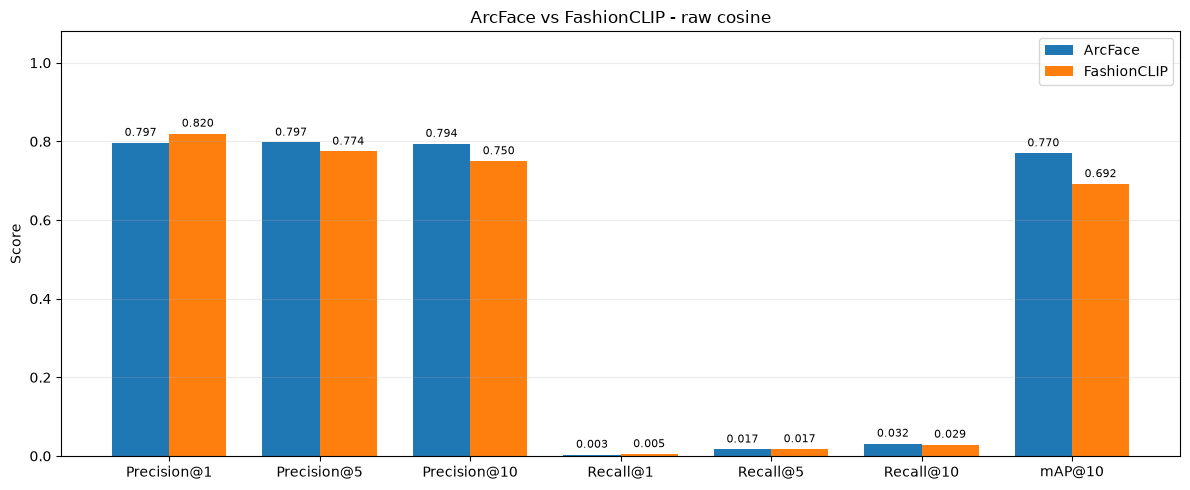

,Precision@1,Precision@5,Precision@10,Recall@1,Recall@5,Recall@10,mAP@10
Model,,,,,,,
arcface,0.7986,0.7998,0.7969,0.0034,0.0167,0.0316,0.7755
EXTERNAL_fashion_clip,0.7517,0.7429,0.7329,0.0027,0.0138,0.0256,0.6720


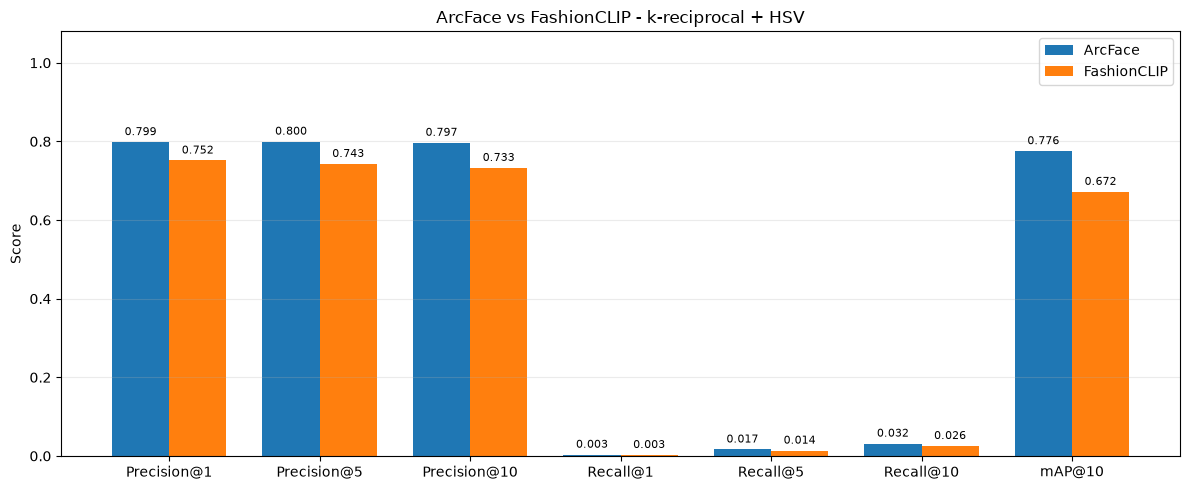

In [48]:
EXTERNAL_METRIC_COLUMNS = [
    "Precision@1",
    "Precision@5",
    "Precision@10",
    "Recall@1",
    "Recall@5",
    "Recall@10",
    "mAP@10",
]
EXTERNAL_COMPARISON_FILES = {
    "raw": BENCHMARK_DIR / "fashionclip_vs_arcface_raw.csv",
    "reranked": BENCHMARK_DIR / "fashionclip_vs_arcface_reranked.csv",
}
EXTERNAL_COMPARISON_IMAGE_DIR = ARTIFACT_DIR / "images"
EXTERNAL_COMPARISON_IMAGE_DIR.mkdir(parents=True, exist_ok=True)

external_comparison_tables = {
    ranking_type: pd.read_csv(csv_path, index_col="Model").loc[
        ["arcface", "EXTERNAL_fashion_clip"], EXTERNAL_METRIC_COLUMNS
    ]
    for ranking_type, csv_path in EXTERNAL_COMPARISON_FILES.items()
}

metric_positions = np.arange(len(EXTERNAL_METRIC_COLUMNS))
bar_width = 0.38
for ranking_type, table in external_comparison_tables.items():
    display(
        table.style.format("{:.4f}")
        .highlight_max(
            axis=0,
            props="font-weight: 700; text-decoration: underline;",
        )
        .set_caption(
            "ArcFace vs FashionCLIP: "
            + ("raw cosine" if ranking_type == "raw" else "k-reciprocal + HSV")
        )
    )

    fig, ax = plt.subplots(figsize=(12, 5))
    arcface_bars = ax.bar(
        metric_positions - bar_width / 2,
        table.loc["arcface"].to_numpy(dtype=float),
        bar_width,
        label="ArcFace",
    )
    fashionclip_bars = ax.bar(
        metric_positions + bar_width / 2,
        table.loc["EXTERNAL_fashion_clip"].to_numpy(dtype=float),
        bar_width,
        label="FashionCLIP",
    )
    ax.bar_label(arcface_bars, fmt="%.3f", padding=3, fontsize=8)
    ax.bar_label(fashionclip_bars, fmt="%.3f", padding=3, fontsize=8)
    ax.set_xticks(metric_positions, EXTERNAL_METRIC_COLUMNS)
    ax.set_ylim(0, 1.08)
    ax.set_ylabel("Score")
    ax.set_title(
        "ArcFace vs FashionCLIP - "
        + (
            "raw cosine"
            if ranking_type == "raw"
            else "k-reciprocal + HSV"
        )
    )
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    fig.tight_layout()
    figure_path = (
        EXTERNAL_COMPARISON_IMAGE_DIR
        / f"fashionclip_vs_arcface_{ranking_type}.png"
    )
    fig.savefig(figure_path, dpi=300, bbox_inches="tight")
    plt.show()


**Interpretation.** ArcFace produces the stronger overall ranking, although FashionCLIP gives the best unreranked first match.

- **Raw representation quality:** FashionCLIP reaches the higher Precision@1 (0.8201 versus 0.7968), showing that its broad fashion pretraining often identifies a strong nearest neighbour. ArcFace is more consistent deeper in the list: its Precision@5, Precision@10, and mAP@10 are 0.7973, 0.7942, and 0.7702, compared with 0.7744, 0.7499, and 0.6918 for FashionCLIP. The raw mAP@10 advantage for ArcFace is 0.0784.
- **Reranking effects:** reciprocal and HSV reranking raises ArcFace mAP@10 from 0.7702 to 0.7755 and slightly improves all three precision scores. FashionCLIP mAP@10 falls from 0.6918 to 0.6720, while its Precision@1 falls from 0.8201 to 0.7517. ArcFace consequently leads all seven reranked metrics, including mAP@10 by 0.1035.
- **Recall:** the small recall values reflect the evaluation design. Each query can have many relevant gallery items, but retrieval returns at most ten; relative differences are therefore more informative than the absolute recall magnitudes.

ArcFace's advantage is plausible for three reasons:

1. **Alignment with the evaluation labels:** ArcFace was trained directly with the project's `articleType__gender` labels. Its angular-margin objective encourages examples with the same label to form compact clusters while separating different labels [8]. The evaluation uses those same labels to define relevance, so its training objective closely matches the scoring rule.
2. **Different FashionCLIP objective:** FashionCLIP learns broad fashion concepts from image-text pairs [4], [5]. Its embedding can preserve style, colour, material, and other description-related attributes that are useful visually but are not rewarded when relevance is reduced to `articleType__gender`. It is also evaluated frozen, without adaptation to this dataset.
3. **Reranker compatibility:** k-reciprocal reranking benefits embeddings whose local neighbourhoods already follow the relevance labels [2]. The results suggest that ArcFace provides this structure more reliably. HSV blending may also reorder FashionCLIP's strong nearest neighbours because colour similarity is not part of the relevance label.

These explanations are supported by the objectives and observed metric changes, but the comparison cannot isolate one cause: the models also differ in training data, supervision, architecture, and preprocessing.


## 8. Qualitative retrieval examples

Two seeded hold-out queries and their top-three results provide a readable illustration of the current winning pipeline. A check mark means that the proxy label matches; it does not guarantee that a person would judge the products visually interchangeable. Colour, silhouette, pattern and framing can reveal why a formally correct result still looks weak.

The output below is generated from the current winning pipeline, ArcFace. It supports error analysis but does **not** establish that ArcFace looks visually better than every alternative; a direct visual comparison would need to show the same selected queries for multiple models.


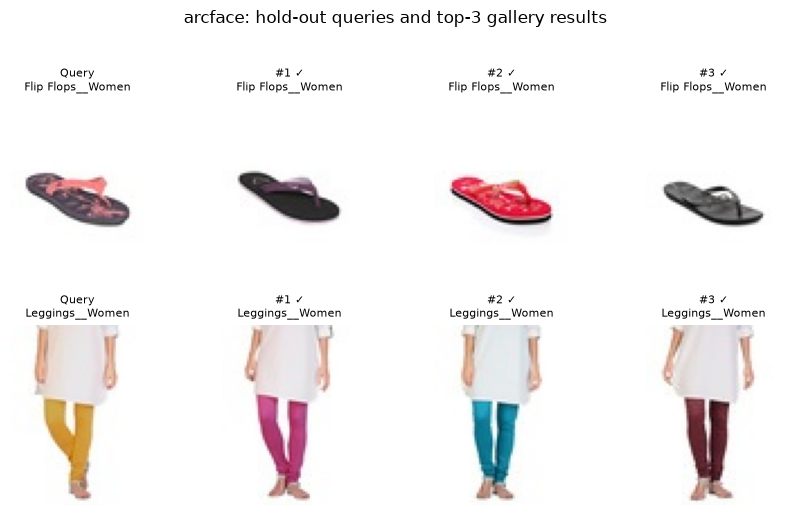

In [25]:
def show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=SEED):
    output = model_outputs[model_name]
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        len(output["query_ids"]),
        size=min(n_queries, len(output["query_ids"])),
        replace=False,
    )
    fig, axes = plt.subplots(
        len(chosen), k + 1, figsize=(2.2 * (k + 1), 2.5 * len(chosen))
    )
    axes = np.atleast_2d(axes)

    for row, query_index in enumerate(chosen):
        query_id = output["query_ids"][query_index]
        query_label = classes[output["query_labels"][query_index]]
        gallery_indices = output["ranked_indices"][query_index, :k]
        ids = [query_id, *output["gallery_ids"][gallery_indices]]
        labels = [query_label, *classes[output["gallery_labels"][gallery_indices]]]
        for column, (item_id, item_label) in enumerate(zip(ids, labels)):
            with Image.open(IMAGE_DIR / f"{int(item_id)}.jpg") as image:
                axes[row, column].imshow(image.convert("RGB"))
            axes[row, column].axis("off")
            if column == 0:
                axes[row, column].set_title(f"Query\n{item_label}", fontsize=8)
            else:
                is_relevant = item_label == query_label
                axes[row, column].set_title(
                    f"#{column} {'✓' if is_relevant else '✗'}\n{item_label}", fontsize=8
                )
    fig.suptitle(f"{model_name}: hold-out queries and top-{k} gallery results", y=1.02)
    fig.tight_layout()
    plt.show()


show_retrieval_examples(model_name=winner, n_queries=2, k=3, seed=42)

## References

[1] J. Johnson, M. Douze, and H. Jégou, "Billion-scale similarity search with GPUs," *IEEE Trans. Big Data*, vol. 7, no. 3, pp. 535-547, 2021, doi: [10.1109/TBDATA.2019.2921572](https://doi.org/10.1109/TBDATA.2019.2921572).

[2] Z. Zhong, L. Zheng, D. Cao, and S. Li, "Re-ranking person re-identification with k-reciprocal encoding," in *Proc. IEEE Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2017, pp. 1318-1327. [Online]. Available: https://openaccess.thecvf.com/content_cvpr_2017/html/Zhong_Re-Ranking_Person_Re-Identification_CVPR_2017_paper.html

[3] C. D. Manning, P. Raghavan, and H. Schütze, *Introduction to Information Retrieval*. Cambridge, U.K.: Cambridge Univ. Press, 2008, ch. 8. [Online]. Available: https://nlp.stanford.edu/IR-book/

[4] P. J. Chia, G. Attanasio, F. Bianchi, S. Terragni, A. R. Magalhães, D. Goncalves, C. Greco, and J. Tagliabue, "Contrastive language and vision learning of general fashion concepts," *Scientific Reports*, vol. 12, Art. no. 18958, 2022, doi: [10.1038/s41598-022-23052-9](https://doi.org/10.1038/s41598-022-23052-9). [Online]. Available: [full text](https://pmc.ncbi.nlm.nih.gov/articles/PMC9643437/).

[5] P. J. Chia *et al.*, "FashionCLIP model card and checkpoint files," Hugging Face, updated Mar. 2023. [Online]. Available: [model card](https://huggingface.co/patrickjohncyh/fashion-clip), [configuration at the evaluated revision](https://huggingface.co/patrickjohncyh/fashion-clip/blob/7e3ba62ce16b379a1ab479346b66f192e76f51b7/config.json), and [preprocessing configuration](https://huggingface.co/patrickjohncyh/fashion-clip/blob/7e3ba62ce16b379a1ab479346b66f192e76f51b7/preprocessor_config.json). Accessed: Sep. 10, 2026.

[6] A. Radford *et al.*, "Learning transferable visual models from natural language supervision," in *Proc. 38th Int. Conf. Mach. Learn. (ICML)*, PMLR, vol. 139, pp. 8748–8763, 2021. [Online]. Available: [PMLR paper](https://proceedings.mlr.press/v139/radford21a.html).

[7] OpenAI, "CLIP: Connecting text and images," Jan. 5, 2021. [Online]. Available: [CLIP overview and architecture figure](https://openai.com/index/clip/). Accessed: Sep. 10, 2026.

[8] J. Deng, J. Guo, N. Xue, and S. Zafeiriou, "ArcFace: Additive angular margin loss for deep face recognition," in *Proc. IEEE/CVF Conf. Comput. Vis. Pattern Recognit. (CVPR)*, 2019, pp. 4690-4699. [Online]. Available: https://openaccess.thecvf.com/content_CVPR_2019/html/Deng_ArcFace_Additive_Angular_Margin_Loss_for_Deep_Face_Recognition_CVPR_2019_paper.html
